# 911 Calls - Data Capstone Project


For this Data Capstone Project - 911 calls data from Kaggle is used.  
Link: https://www.kaggle.com/datasets/mchirico/montcoalert

### Import Numpy, Pandas & Visualization libraries.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

### Load the Data

In [3]:
df = pd.read_csv('911.csv')

In [4]:
df.head(3)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  str    
 3   zip        86637 non-null  float64
 4   title      99492 non-null  str    
 5   timeStamp  99492 non-null  str    
 6   twp        99449 non-null  str    
 7   addr       98973 non-null  str    
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 6.8 MB


### Questions:
Top 5 zipcodes for 911 calls?

In [6]:
df['zip'].value_counts().head(5)

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

Top 5 townships (twp) for 911 calls?

In [7]:
df['twp'].value_counts().head(5)

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

How many unique title codes in 'title columns'?

In [8]:
df['title'].nunique()

110

### Creating new features

1. Creating new column named 'Reason' based on existing column named 'title' in the dataframe.

In [9]:
df['Reason'] = df['title'].str.split(':').apply(lambda title : title[0])
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS


Most common Reason for a 911 call based on new column 'Reason'?

In [10]:
df['Reason'].value_counts()

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

In [11]:
df['Reason'].value_counts().index[0]

'EMS'

### Visualization: Countplot of 911 calls by 'Reason'

C:\Users\vivek\AppData\Local\Temp\ipykernel_21492\2054220447.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x= 'Reason', palette='viridis')


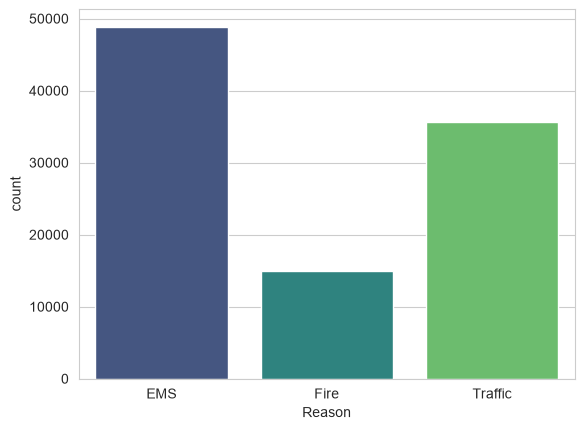

In [12]:
sns.countplot(df, x= 'Reason', palette='viridis')
plt.show()

### Time Information:
Data type of the objects in the timeStamp column? 

In [13]:
type(df['timeStamp'].iloc[0]) 
#grabs the value located in first row of 'timeStamp' column and checks it's DataType.

str

Values in 'timestamp' column are strings. 
Using **'pd.to_datetime'**, we can convert it into DateTime object.

In [14]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

time = df['timeStamp'].iloc[9000]
time.month

1

DateTime objects allow you to grab specific attributes like year, month, day etc.

* Creating 3 new columns called Hour, Month, and Day of Week using newly created DateTime objects from 'timestamp' columns

In [15]:
df['Hour'] = df['timeStamp'].apply(lambda x : x.hour)
df['Month'] = df['timeStamp'].apply(lambda x : x.month)
df['Day of Week'] = df['timeStamp'].apply(lambda x : x.dayofweek)
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,3
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,3
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,12,3
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,17,12,3
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,17,12,3


In [16]:
df['Day of Week'].value_counts()

Day of Week
1    15150
2    14879
4    14833
0    14680
3    14478
5    13336
6    12136
Name: count, dtype: int64

We can see 'Day of Week' Column is an integer from '1 to 6'. We can use .map() to map actual string names to to values in the 'Day of Week' Column.

In [17]:
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [19]:
df['Day of Week'] = df['Day of Week'].map(dmap)
df['Day of Week'].value_counts()

Day of Week
Tue    15150
Wed    14879
Fri    14833
Mon    14680
Thu    14478
Sat    13336
Sun    12136
Name: count, dtype: int64

### Visualization: countplot of the 'Day of Week' column

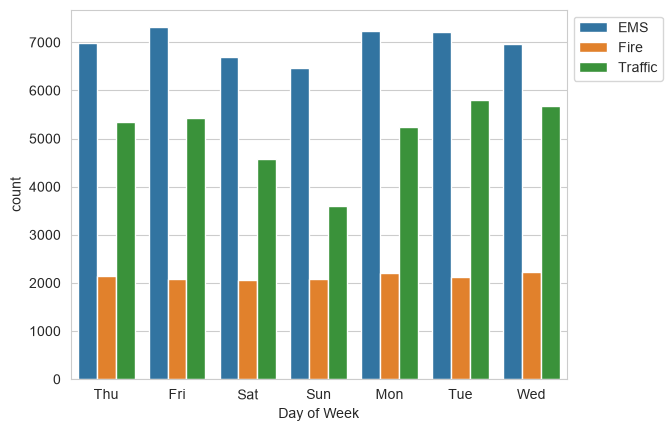

In [22]:
sns.countplot(df, x = 'Day of Week', hue = 'Reason')
plt.legend(loc=0, bbox_to_anchor = (1,1)) # moving the legend outside the plot for clear visibility.

### Visualization: countplot of the 'Month' column

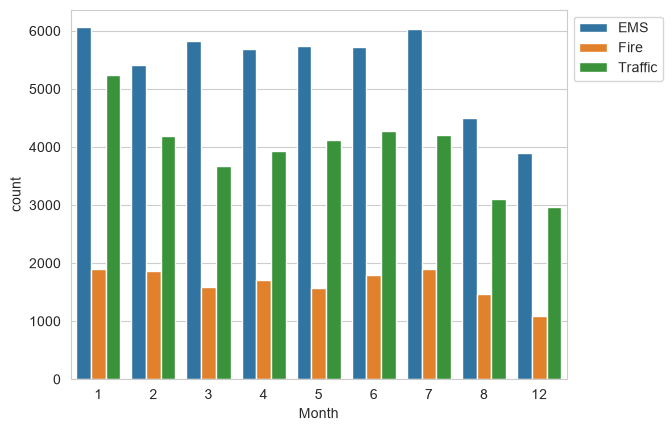

In [23]:
sns.countplot(df, x='Month', hue = 'Reason')
plt.legend(loc=2, bbox_to_anchor=(1,1))

In [28]:
sorted(df['Month'].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(12)]

From the above plot and sorted list of 'Month' column, we can see some missing Months (9,10,11).

We can fill the missing information by a simple line plot. To do that :  
Create a groupby object to group the Dataframe by 'Month' Column.

In [31]:
byMonth = df.groupby(['Month']).count()  
byMonth       

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Day of Week
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423
6,11786,11786,11786,10212,11786,11786,11777,11732,11786,11786,11786,11786
7,12137,12137,12137,10633,12137,12137,12133,12088,12137,12137,12137,12137
8,9078,9078,9078,7832,9078,9078,9073,9025,9078,9078,9078,9078
12,7969,7969,7969,6907,7969,7969,7963,7916,7969,7969,7969,7969


Using .count() gives you clean 9 data-points for each column (Ideal for plottng).
Not using it would result in very large no. of rows for each Column&Index (as each index will have multiple row entry for same column.)  
* Note: df - lots of rows(difficult to plot) / byMonth - Only 9 rows(ideal for lmplot)

### Visulaization: Line plot of 'byMonth' - indicating count of calls per month.

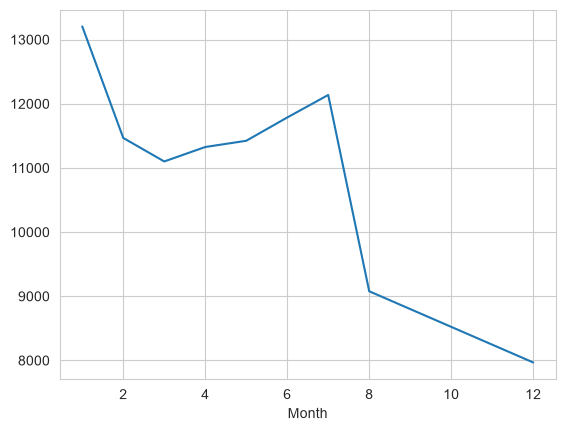

In [32]:
byMonth['lat'].plot() #Index is the x-axis(by default) in Pandas.
plt.show()

* Using seaborn's lmplot() to create a linear fit on the number of calls per month.

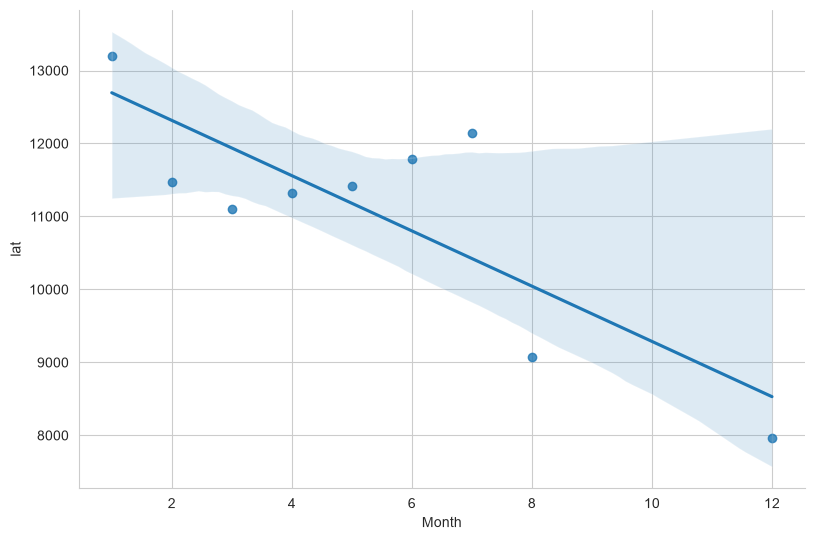

In [46]:
sns.lmplot(byMonth.reset_index(), x='Month', y='lat', height=5.5, aspect=1.5)

* Creating new column 'Date' from the 'timeStamp' column & group the Dataframe using that column.

In [47]:
df['Date'] = df['timeStamp'].apply(lambda t : t.date())

In [48]:
byDate = df.groupby('Date').count()

### Visulaization: Count plot of 'byDate' - indicating counts of 911 calls.

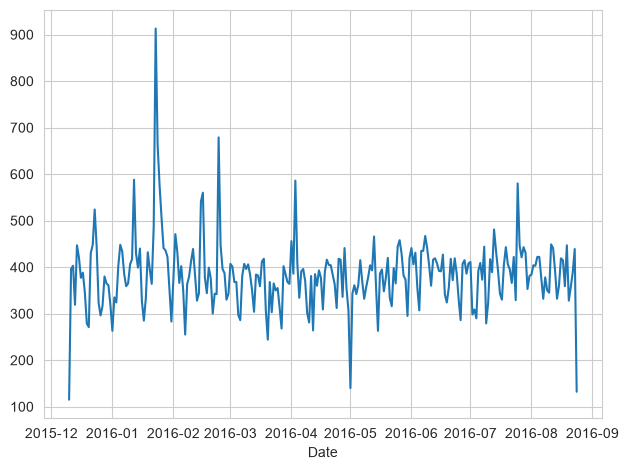

In [49]:
byDate['lat'].plot()
plt.tight_layout()

### Recreating the above plot but each plot representing 'Reason' for the 911 call.

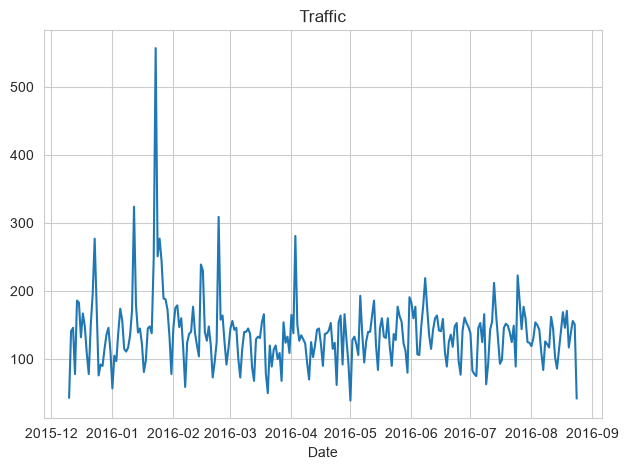

In [54]:
tfc = df[df['Reason'] == 'Traffic'].groupby('Date').count()
tfc['lat'].plot()
plt.title('Traffic')
plt.tight_layout()

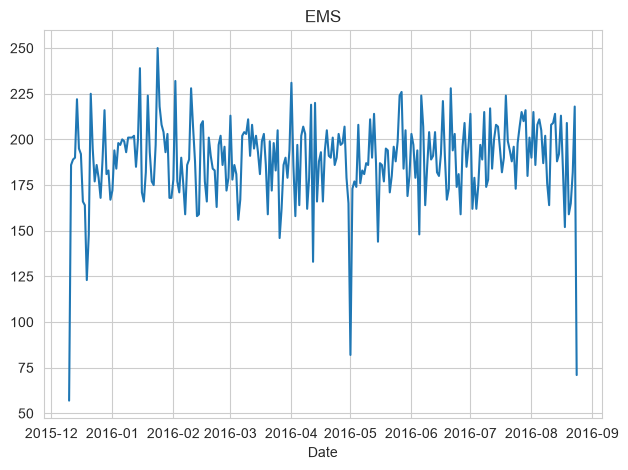

In [51]:
ems = df[df['Reason'] == 'EMS'].groupby('Date').count()
ems['lat'].plot(title = 'EMS')
plt.tight_layout()

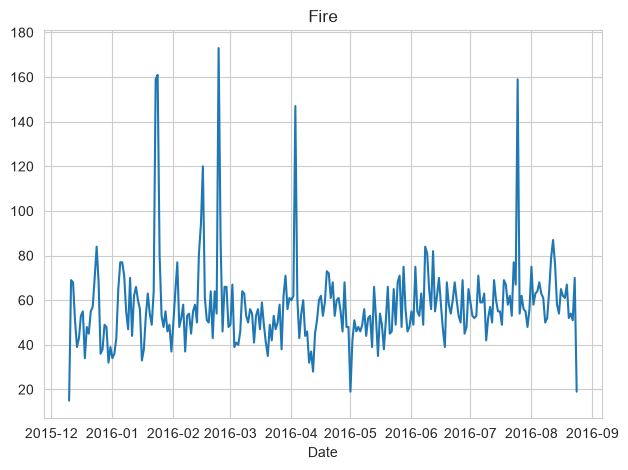

In [52]:
fr = df[df['Reason'] == 'Fire'].groupby('Date').count()
fr['lat'].plot(title = 'Fire') # In place of 'lat' any other column can also be used like 'Reason'.
plt.tight_layout()

### HeatMaps and Cluster Maps.

For Heatmaps we need to restructure the Dataframe so that the columns become the 'Hours' and the Index becomes the 'Day of Week'. Two ways to do this:  
1.Using .pivot_table   
2.Using .groupby() with .unstack()


In [61]:
#option-1:
pivotdf = df.pivot_table(values='Reason',index='Day of Week',columns='Hour', aggfunc='count')
pivotdf
# In place of 'lat' any other column can also be used like 'Reason'.

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354
Tue,269,240,186,170,209,239,415,655,889,880,...,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,...,904,867,990,1037,894,686,668,575,490,335


### Visualization: HeatMap 

<Axes: xlabel='Hour', ylabel='Day of Week'>

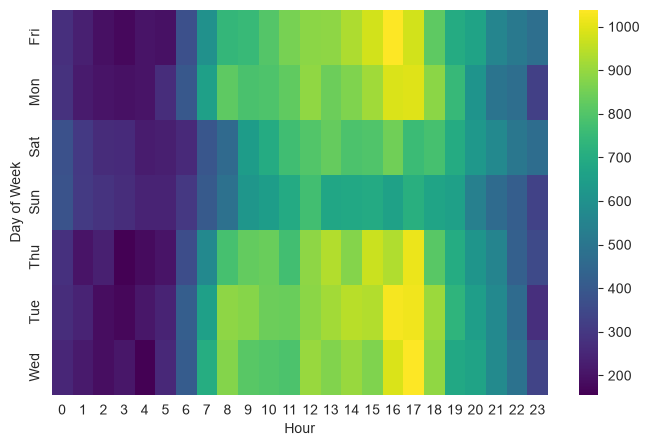

In [57]:
plt.figure(figsize=(8,5))
sns.heatmap(pivotdf,cmap='viridis')

### Visualization: ClusterMap

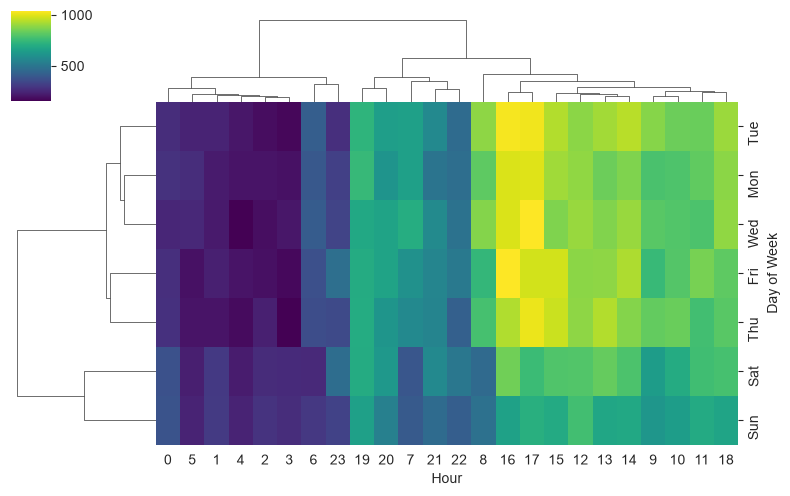

In [58]:
sns.clustermap(pivotdf, figsize=(8,5), cmap='viridis')

**Observation:** Above HeatMap and ClusterMap show - Highest call count at around '16-17 hours' &   
Least call count on 'Sat/Sun' and also very low call count at around Hour '0 to 6' 

* Repeating - For 'Month' as column and 'Day of Week' as rows.

In [60]:
#option-2:
byMonth = df.groupby(['Day of Week', 'Month'])['lat'].count().unstack() 
byMonth

Month,1,2,3,4,5,6,7,8,12
Day of Week,,,,,,,,,
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Sun,1960,1229,1102,1488,1424,1333,1672,1021,907
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266
Tue,1973,1753,1884,1430,1918,1676,1670,1612,1234
Wed,1700,1903,1889,1517,1538,2058,1717,1295,1262


### Visualization: HeatMap

<Axes: xlabel='Month', ylabel='Day of Week'>

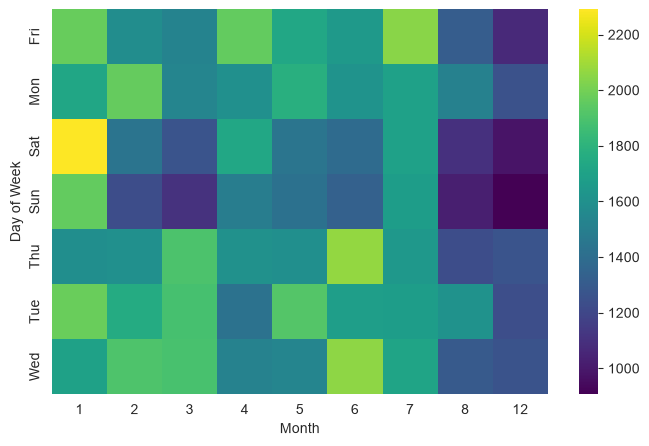

In [62]:
plt.figure(figsize=(8,5))
sns.heatmap(byMonth, cmap='viridis')

### Visualization: ClusterMap

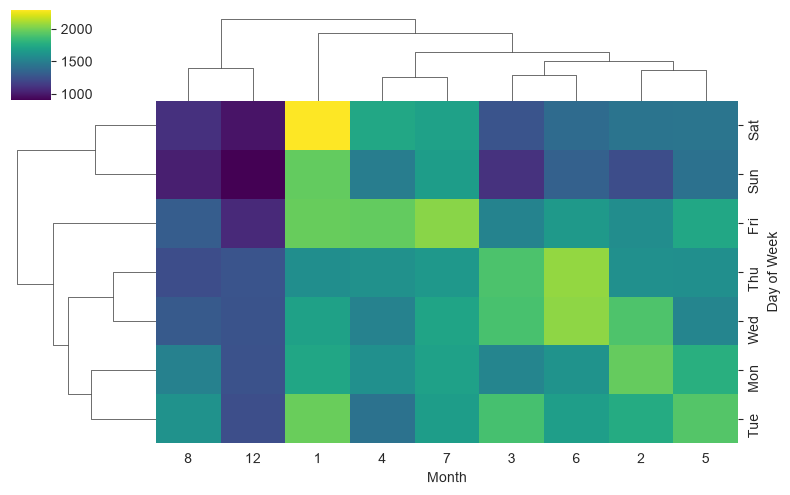

In [63]:
sns.clustermap(byMonth, cmap='viridis', figsize=(8,5))

**Observation:** Least call count at Month '8 and 12' & Highest call count in Month '1'.